In [1]:
# =========================
# 1. Setup: imports, load data, generate cluster labels, train/test split
# =========================
# This notebook treats the KMeans cluster as the supervised target. We re-run
# the clustering here so the notebook is self-contained and doesn't depend on
# variables left over from k-means_analysis.ipynb.
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

df = pd.read_csv("top_colleges_2022.csv")

features = [
    "medianBaseSalary",
    "studentFacultyRatio",
    "percentOfStudentsFinAid",
    "percentOfStudentsGrant",
    "totalStudentPop"
]

X = df[features].copy()
X = X.fillna(X.median())

# Regenerate cluster labels (same setup as the k-means notebook)
scaler_full = StandardScaler()
X_scaled_full = scaler_full.fit_transform(X)
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
df["cluster"] = kmeans.fit_predict(X_scaled_full)

y = df["cluster"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.25,
    random_state=42,
    stratify=y
)

print("Train size:", X_train.shape, " Test size:", X_test.shape)
print("Class distribution in train:")
print(y_train.value_counts().sort_index())

Train size: (373, 5)  Test size: (125, 5)
Class distribution in train:
cluster
0     73
1    170
2    130
Name: count, dtype: int64


In [2]:
# =========================
# 2. Scale data for Logistic Regression
# =========================
# Logistic regression is sensitive to feature scale (salary in 100,000s would
# dominate ratios in single digits). Random Forest does not need scaling.
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [3]:
# =========================
# 3. Logistic Regression model
# =========================
log_model = LogisticRegression(max_iter=1000, random_state=42)
log_model.fit(X_train_scaled, y_train)
log_preds = log_model.predict(X_test_scaled)

log_acc = accuracy_score(y_test, log_preds)
print("Logistic Regression Accuracy:", round(log_acc, 4))
print()
print(classification_report(y_test, log_preds))

Logistic Regression Accuracy: 1.0

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        24
           1       1.00      1.00      1.00        57
           2       1.00      1.00      1.00        44

    accuracy                           1.00       125
   macro avg       1.00      1.00      1.00       125
weighted avg       1.00      1.00      1.00       125



In [4]:
# =========================
# 4. Random Forest model
# =========================
rf_model = RandomForestClassifier(n_estimators=200, random_state=42)
rf_model.fit(X_train, y_train)
rf_preds = rf_model.predict(X_test)

rf_acc = accuracy_score(y_test, rf_preds)
print("Random Forest Accuracy:", round(rf_acc, 4))
print()
print(classification_report(y_test, rf_preds))

Random Forest Accuracy: 0.968

              precision    recall  f1-score   support

           0       0.96      0.92      0.94        24
           1       0.97      1.00      0.98        57
           2       0.98      0.95      0.97        44

    accuracy                           0.97       125
   macro avg       0.97      0.96      0.96       125
weighted avg       0.97      0.97      0.97       125



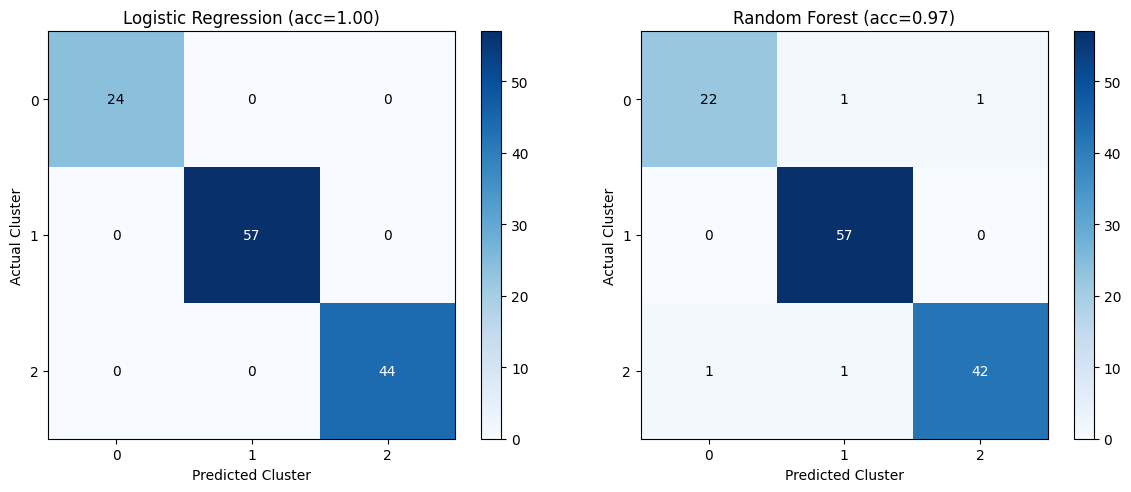

In [5]:
# =========================
# 5. Confusion matrices for both models (side by side)
# =========================
# Plotting both confusion matrices side by side makes it obvious which model is
# making more errors and on which clusters those errors land.
cm_log = confusion_matrix(y_test, log_preds)
cm_rf = confusion_matrix(y_test, rf_preds)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for ax, cm, title in [(axes[0], cm_log, f"Logistic Regression (acc={log_acc:.2f})"),
                       (axes[1], cm_rf, f"Random Forest (acc={rf_acc:.2f})")]:
    im = ax.imshow(cm, cmap="Blues")
    ax.set_title(title)
    ax.set_xlabel("Predicted Cluster")
    ax.set_ylabel("Actual Cluster")
    ax.set_xticks(range(len(cm)))
    ax.set_yticks(range(len(cm)))
    for i in range(len(cm)):
        for j in range(len(cm[i])):
            ax.text(j, i, cm[i][j], ha="center", va="center",
                    color="white" if cm[i][j] > cm.max() / 2 else "black")
    fig.colorbar(im, ax=ax, fraction=0.046)

plt.tight_layout()
plt.savefig("confusion_matrices.png", dpi=150)
plt.show()

In [6]:
# =========================
# 6. Feature importance (from Random Forest)
# =========================
importance_df = pd.DataFrame({
    "Feature": features,
    "Importance": rf_model.feature_importances_
}).sort_values(by="Importance", ascending=False)

importance_df

,Feature,Importance
2,percentOfStudentsFinAid,0.243984
1,studentFacultyRatio,0.240245
3,percentOfStudentsGrant,0.213201
4,totalStudentPop,0.198918
0,medianBaseSalary,0.103652


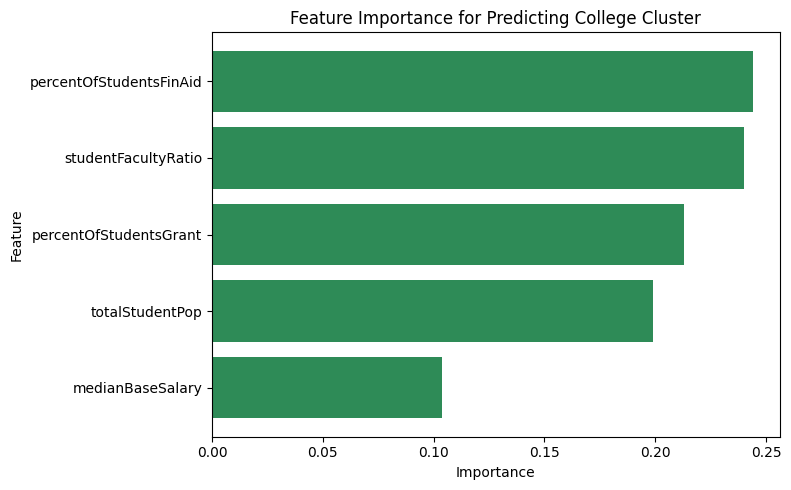

In [7]:
# =========================
# 7. Feature importance bar chart
# =========================
# Which raw features drive the cluster assignment? Anything close to zero is
# basically noise for this task; the top bar is the dominant separator.
plt.figure(figsize=(8, 5))
plt.barh(importance_df["Feature"], importance_df["Importance"], color="seagreen")
plt.gca().invert_yaxis()
plt.title("Feature Importance for Predicting College Cluster")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.tight_layout()
plt.savefig("feature_importance.png", dpi=150)
plt.show()

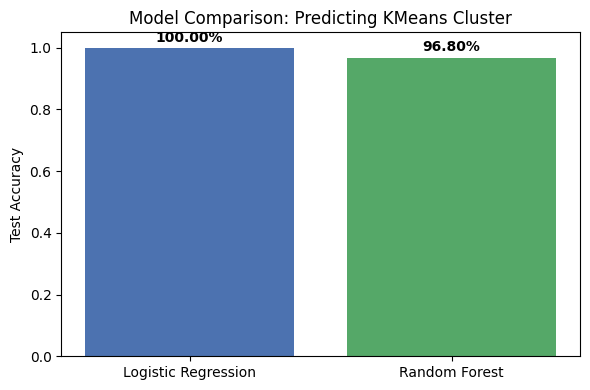

In [8]:
# =========================
# 8. Model accuracy comparison
# =========================
# A single side-by-side bar makes the headline result easy to read at a glance.
models = ["Logistic Regression", "Random Forest"]
accuracies = [log_acc, rf_acc]

plt.figure(figsize=(6, 4))
bars = plt.bar(models, accuracies, color=["#4c72b0", "#55a868"])
plt.ylim(0, 1.05)
plt.ylabel("Test Accuracy")
plt.title("Model Comparison: Predicting KMeans Cluster")
for b, a in zip(bars, accuracies):
    plt.text(b.get_x() + b.get_width() / 2, a + 0.02, f"{a:.2%}",
             ha="center", fontweight="bold")
plt.tight_layout()
plt.savefig("model_comparison.png", dpi=150)
plt.show()

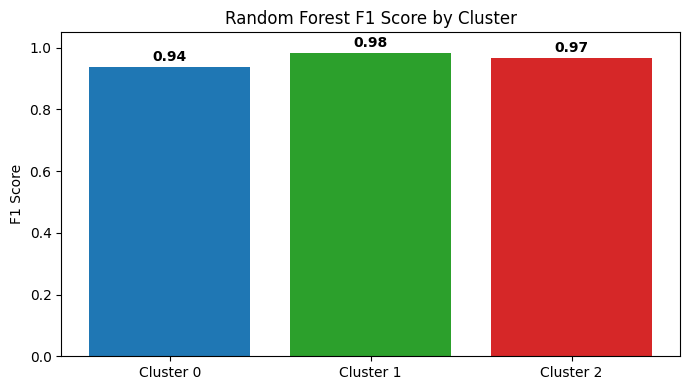

In [9]:
# =========================
# 9. Per-cluster F1 scores
# =========================
# Overall accuracy can hide one weak class. Per-cluster F1 shows whether the
# Random Forest is uniformly strong or just doing well on the majority cluster.
from sklearn.metrics import f1_score

f1_per_cluster = f1_score(y_test, rf_preds, average=None)
clusters_sorted = sorted(y.unique())

plt.figure(figsize=(7, 4))
bars = plt.bar([f"Cluster {c}" for c in clusters_sorted], f1_per_cluster,
                color=["#1f77b4", "#2ca02c", "#d62728"])
plt.ylim(0, 1.05)
plt.ylabel("F1 Score")
plt.title("Random Forest F1 Score by Cluster")
for b, f in zip(bars, f1_per_cluster):
    plt.text(b.get_x() + b.get_width() / 2, f + 0.02, f"{f:.2f}",
             ha="center", fontweight="bold")
plt.tight_layout()
plt.savefig("f1_per_cluster.png", dpi=150)
plt.show()